In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv


In [3]:
df = pd.read_csv("historical_data.csv")
df.sample(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
173052,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,19.700,100.87,1987.14,BUY,25-02-2025 22:53,-2982.66,Close Short,10.127348,0x7453fc1b32f0fe3db619041e73b762016a004d056deb...,74914813091,False,0.198713,1.010000e+15,1.740000e+12
45658,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,@107,17.980,9.94,178.72,SELL,12-12-2024 16:09,61137.73,Sell,178.721101,0x00000000000000000000000000000000000000000000...,54883143825,False,0.017872,6.680000e+13,1.730000e+12
127676,0x47add9a56df66b524d5e2c1993a43cde53b6ed85,PURR,0.120,6250.00,750.00,SELL,21-03-2025 23:56,-31679.00,Open Short,0.000000,0x3310afde9d6f02a211c20420007c3e01d30092452e59...,81149442707,False,0.072000,9.970000e+14,1.740000e+12
170287,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,24.930,4.62,115.18,SELL,20-02-2025 10:15,-98.57,Open Short,0.000000,0xdd2d7cff922f2f348618041e1a110301b00031c55be1...,73563220482,True,0.040311,3.540000e+13,1.740000e+12
128892,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,LTC,89.706,0.55,49.34,BUY,18-11-2024 20:12,-1.19,Close Short,0.411125,0x402fb43f038235e1735e04171cea80020103008443da...,48281685955,True,0.017268,1.650000e+14,1.730000e+12


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [5]:
df = df.iloc[:, [1,2,3,4,5,6,7,8,9,12,13]]
df.sample(5)

,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Crossed,Fee
21537,ETH,3511.4000,0.4272,1500.07,BUY,10-04-2024 23:46,0.5696,Open Long,0.00000,True,0.525024
66377,HYPE,21.0510,196.4400,4135.26,BUY,24-02-2025 20:23,40445.6000,Open Long,0.00000,False,0.396984
29328,WLD,6.5860,152.0000,1001.07,SELL,19-02-2024 09:53,2017.8000,Close Long,38.85576,False,-0.020021
85968,HYPE,24.7420,5.0000,123.71,BUY,15-12-2024 07:19,214.8600,Open Long,0.00000,False,0.006185
19113,LAYER,2.4584,24.0000,59.00,SELL,26-04-2025 00:19,-94352.0000,Open Short,0.00000,False,0.005900


In [6]:
# Count of unique values in each object column

for i in df.columns:
  if df[i].dtype == 'O':
    print(i, len(df[i].unique()))

Coin 246
Side 2
Timestamp IST 27977
Direction 12


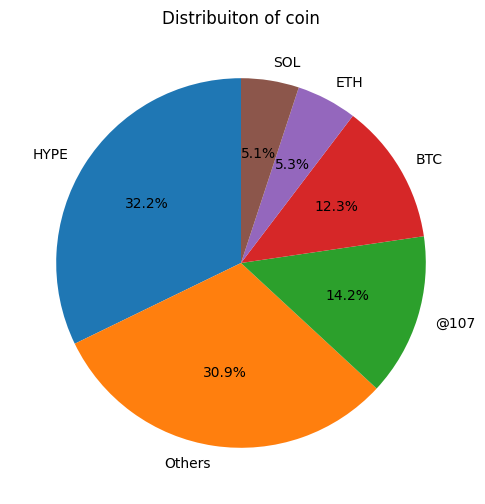

In [7]:
# lets create a pie chart to visualize the distribution
orginal_counts = df['Coin'].value_counts()

top_n = 5 # Only top 5 and rest categorized as Others
top_categories = orginal_counts.nlargest(top_n).index
a =  df['Coin'].apply(lambda x: x if x in top_categories else 'Others')

counts = a.value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct = '%1.1f%%', startangle=90)
plt.title('Distribuiton of coin')
plt.show()

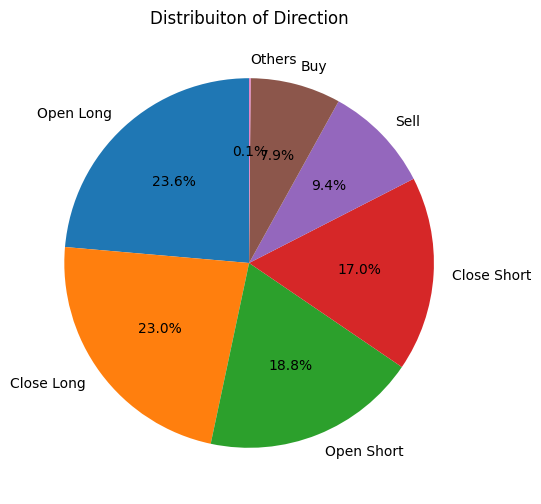

In [8]:
orginal_counts = df['Direction'].value_counts()

top_n = 6 # Only top 6 and rest categorized as Others
top_categories = orginal_counts.nlargest(top_n).index
a =  df['Direction'].apply(lambda x: x if x in top_categories else 'Others')

counts = a.value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct = '%1.1f%%', startangle=90)
plt.title('Distribuiton of Direction')
plt.show()

In [9]:
df['Side'].value_counts()

,count
Side,
SELL,108528
BUY,102696


In [10]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Fee
count,211224.00,211224.00,211224.00,211224.00,211224.00,211224.00
mean,11414.72,4623.36,5639.45,-29946.25,48.75,1.16
std,29447.65,104272.89,36575.14,673807.42,919.16,6.76
min,0.00,0.00,0.00,-14334629.00,-117990.10,-1.18
25%,4.85,2.94,193.79,-376.23,0.00,0.02
50%,18.28,32.00,597.05,84.73,0.00,0.09
75%,101.58,187.90,2058.96,9337.28,5.79,0.39
max,109004.00,15822438.00,3921430.72,30509482.00,135329.09,837.47


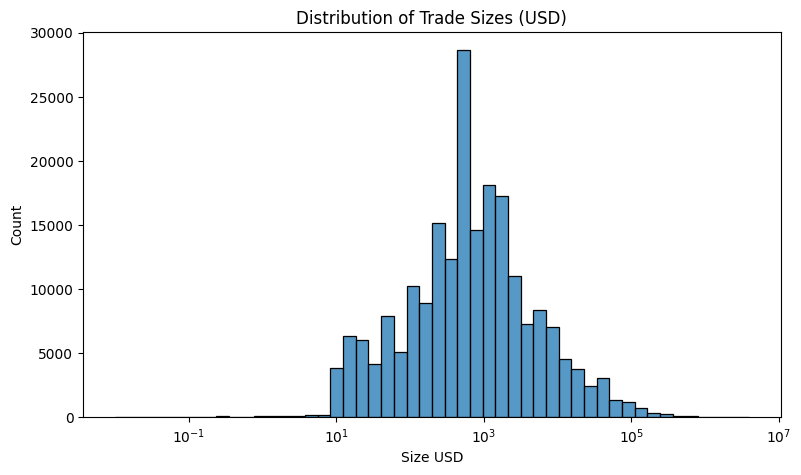

In [11]:
# Histogram of trade size
plt.figure(figsize=(9,5))
sns.histplot(df['Size USD'], bins=50, log_scale=True)
plt.title('Distribution of Trade Sizes (USD)')
plt.xlabel('Size USD')
plt.ylabel('Count')
plt.show()

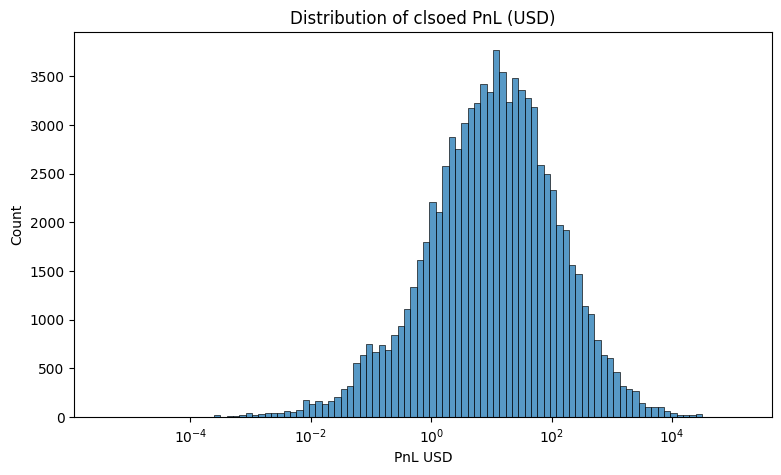

In [12]:
# Histogram of PnL
plt.figure(figsize=(9,5))
sns.histplot(df['Closed PnL'], bins=100, log_scale=True)
plt.title('Distribution of clsoed PnL (USD)')
plt.xlabel('PnL USD')
plt.ylabel('Count')
plt.show()

In [13]:
df['Timestamp IST'] = pd.to_datetime(df['Timestamp IST'], format="%d-%m-%Y %H:%M")
df.sample(3)

,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Crossed,Fee
48587,HYPE,24.50,645.83,15820.90,BUY,2025-02-06 04:19:00,-12346.81,Close Short,1304.77,True,5.54
126128,USUAL,0.42,1971.90,828.20,SELL,2025-01-31 18:11:00,-12278.00,Open Short,0.00,False,0.08
42139,BTC,42457.00,0.01,500.14,SELL,2024-02-06 02:50:00,-1.30,Open Short,0.00,True,0.13


In [14]:
df['date'] = pd.to_datetime((df['Timestamp IST'].dt.date), format='%Y-%m-%d')

In [15]:
# fear greed index

In [16]:
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv


In [17]:
df2 = pd.read_csv('fear_greed_index.csv')
df2 = df2.iloc[:,1:]
df2.sample(5)

,value,classification,date
1749,23,Extreme Fear,19-11-2022
1150,72,Greed,30-03-2021
1613,18,Extreme Fear,06-07-2022
1948,44,Fear,06-06-2023
1666,28,Fear,28-08-2022


In [18]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   value           2644 non-null   int64 
 1   classification  2644 non-null   object
 2   date            2644 non-null   object
dtypes: int64(1), object(2)
memory usage: 62.1+ KB


In [19]:
df2.describe()

,value
count,2644.00
mean,46.98
std,21.83
min,5.00
25%,28.00
50%,46.00
75%,66.00
max,95.00


In [20]:
df2['date'] = pd.to_datetime(df2['date'], format='%d-%m-%Y')

In [21]:
df2['year'] = df2['date'].dt.year
df2.sample(5)

,value,classification,date,year
1490,22,Extreme Fear,2022-03-05,2022
1026,93,Extreme Greed,2020-11-26,2020
873,40,Fear,2020-06-26,2020
1684,28,Fear,2022-09-15,2022
1562,14,Extreme Fear,2022-05-16,2022


In [22]:
df2['year'].unique()

array([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025], dtype=int32)

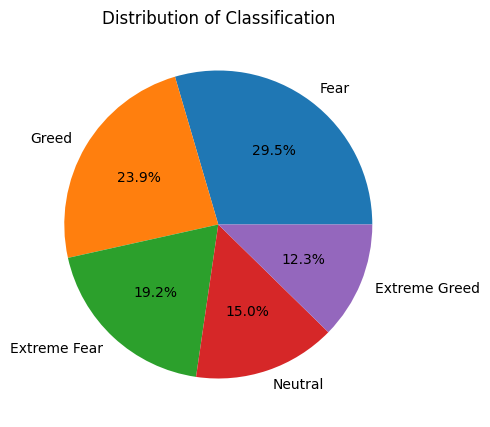

In [23]:
# Calssification pie chart

counts = df2['classification'].value_counts()

plt.figure(figsize=(9,5))
plt.pie(counts, labels=counts.index , autopct='%1.1f%%')
plt.title('Distribution of Classification')
plt.show()

In [24]:
df2.groupby('classification')['value'].mean().sort_values(ascending=False)

,value
classification,
Extreme Greed,82.12
Greed,65.85
Neutral,49.96
Fear,34.18
Extreme Fear,18.27


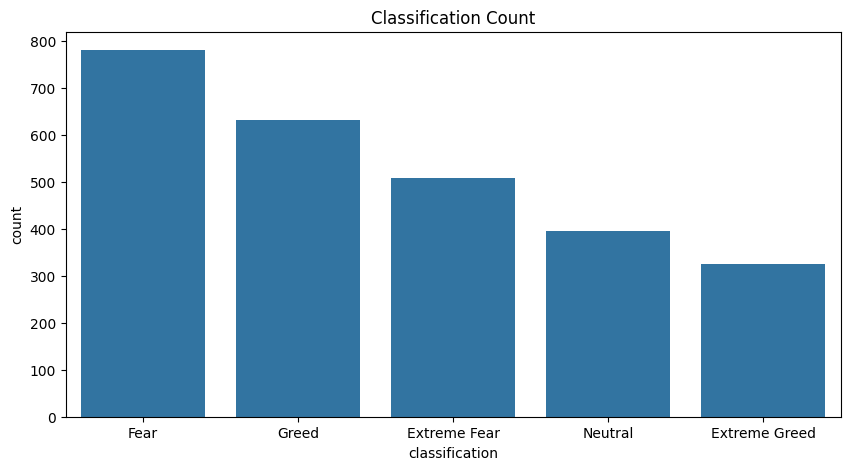

In [25]:
# Counts
plt.figure(figsize=(10,5))
sns.countplot(x='classification', data=df2, order=df2['classification'].value_counts().index)
plt.title('Classification Count')
plt.show()

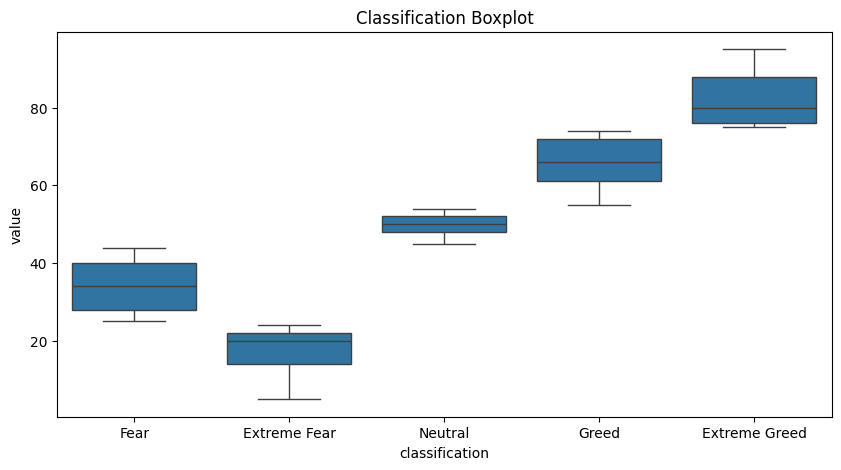

In [26]:
plt.figure(figsize=(10,5))
sns.boxplot(x='classification', y='value', data=df2)
plt.title('Classification Boxplot')
plt.show()

In [27]:
# Merging both datasets

In [28]:
merged_df = pd.merge(df, df2, how='left', on='date')
merged_df.sample(5)

,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Crossed,Fee,date,value,classification,year
201635,HYPE,24.16,82.76,1999.81,SELL,2025-01-23 05:54:00,6277.43,Close Long,99.30,True,0.70,2025-01-23,75.00,Extreme Greed,2025.00
204139,SEI,0.28,3365.00,932.98,SELL,2025-02-24 03:52:00,-118033.00,Open Short,0.00,True,0.33,2025-02-24,49.00,Neutral,2025.00
133444,kBONK,0.04,1301.00,49.98,BUY,2024-12-13 03:09:00,-5324.00,Close Short,1.28,True,0.02,2024-12-13,76.00,Extreme Greed,2024.00
17452,SOL,172.59,2.89,498.79,BUY,2025-03-03 07:22:00,-3517.59,Close Short,102.60,False,0.02,2025-03-03,33.00,Fear,2025.00
26362,BTC,103317.00,0.00,10.33,SELL,2025-01-21 05:10:00,1.45,Close Long,0.06,True,0.00,2025-01-21,76.00,Extreme Greed,2025.00


In [29]:
merged_df.info() # missing values after merging

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Coin             211224 non-null  object        
 1   Execution Price  211224 non-null  float64       
 2   Size Tokens      211224 non-null  float64       
 3   Size USD         211224 non-null  float64       
 4   Side             211224 non-null  object        
 5   Timestamp IST    211224 non-null  datetime64[ns]
 6   Start Position   211224 non-null  float64       
 7   Direction        211224 non-null  object        
 8   Closed PnL       211224 non-null  float64       
 9   Crossed          211224 non-null  bool          
 10  Fee              211224 non-null  float64       
 11  date             211224 non-null  datetime64[ns]
 12  value            211218 non-null  float64       
 13  classification   211218 non-null  object        
 14  year             211

In [30]:
merged_df.dropna(inplace=True)
merged_df.isnull().sum()

,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0
Crossed,0


In [31]:
merged_df['year'] = merged_df['year'].astype(int)

In [41]:
summary = merged_df.groupby('classification').agg({
    'Closed PnL': ['mean', 'sum'],
    'Size USD': 'mean',
    'Fee': 'sum',
    'Side': 'count'
})
summary

Closed PnL            Size USD      Fee   Side
                     mean        sum     mean      sum  count
classification                                               
Extreme Fear        34.54  739110.25  5349.73 23888.63  21400
Extreme Greed       67.89 2715171.31  3112.25 27030.67  39992
Fear                54.29 3357155.44  7816.11 92456.95  61837
Greed               42.74 2150129.27  5736.88 63098.69  50303
Neutral             34.31 1292920.68  4782.73 39374.27  37686

In [33]:
merged_df['day_name'] = merged_df['date'].dt.day_name()

In [34]:
merged_df['date_is_weekend'] = np.where(merged_df['day_name'].isin(['Saturday', 'Sunday']), 1,0)

In [35]:
merged_df.sample(3)

,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Crossed,Fee,date,value,classification,year,day_name,date_is_weekend
30244,DOGE,0.18,55333.00,9863.66,BUY,2024-03-04 21:55:00,-238024.00,Close Short,344.72,False,-0.20,2024-03-04,82.00,Extreme Greed,2024,Monday,0
127393,SUI,2.45,612.20,1499.89,BUY,2025-03-04 12:40:00,1517.40,Open Long,0.00,False,0.14,2025-03-04,15.00,Extreme Fear,2025,Tuesday,0
32987,ZEREBRO,0.43,402.00,172.75,BUY,2025-01-07 21:12:00,-20034.00,Close Short,7.49,False,0.02,2025-01-07,78.00,Extreme Greed,2025,Tuesday,0


In [36]:
merged_df['date_is_weekend'].value_counts()

,count
date_is_weekend,
0,170689
1,40529


In [37]:
merged_df.loc[merged_df['date_is_weekend'] == 1].mean(numeric_only=True)

,0
Execution Price,11081.39
Size Tokens,4603.89
Size USD,6110.67
Start Position,6844.09
Closed PnL,58.15
Crossed,0.66
Fee,1.33
value,54.32
year,2024.71
date_is_weekend,1.00


In [38]:
merged_df.loc[merged_df['date_is_weekend'] == 0].mean(numeric_only=True)

,0
Execution Price,11494.27
Size Tokens,4627.96
Size USD,5527.24
Start Position,-38682.45
Closed PnL,46.27
Crossed,0.60
Fee,1.13
value,51.02
year,2024.76
date_is_weekend,0.00


In [39]:
merged_df['profitable'] = (merged_df['Closed PnL']>0).astype(int)

win_loss = merged_df.groupby('classification')['profitable'].agg(
    total_trades = 'count',
    profitable_trades = 'sum'
)

win_loss['win_rate'] = (win_loss['profitable_trades']/win_loss['total_trades'])*100

In [40]:
win_loss.sort_values(by='win_rate', ascending=False)

,total_trades,profitable_trades,win_rate
classification,,,
Extreme Greed,39992,18594,46.49
Fear,61837,26019,42.08
Neutral,37686,14961,39.70
Greed,50303,19358,38.48
Extreme Fear,21400,7931,37.06
